# Lecture 1: Practice Exercises — Answer Key
### NLP Course 2027

---

This notebook provides complete answers for the four exercises in **Lecture 1: Introduction to NLP & Text Processing**.

In [1]:
import nltk

for pkg in ['book', 'punkt', 'punkt_tab', 'stopwords', 'wordnet',
            'averaged_perceptron_tagger', 'maxent_ne_chunker', 'words']:
    nltk.download(pkg, quiet=True)

from nltk.book import text1, text2, text3, text4, text5, text6
print('NLTK texts loaded.')

*** Introductory Examples for the NLTK Book ***
Loading text1, ..., text9 and sent1, ..., sent9
Type the name of the text or sentence to view it.
Type: 'texts()' or 'sents()' to list the materials.
text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text5: Chat Corpus
text6: Monty Python and the Holy Grail
text7: Wall Street Journal
text8: Personals Corpus
text9: The Man Who Was Thursday by G . K . Chesterton 1908
NLTK texts loaded.


---
## Exercise 1.1

**Task:** Write a function `lexical_diversity(text)` that computes the ratio of unique words to total words. Compare all six NLTK texts.

**Concept:** *Lexical diversity* (also called *type-token ratio*) measures how varied the vocabulary is.  
A higher ratio means a more varied vocabulary; a lower ratio indicates lots of repetition.

$$\text{lexical diversity} = \frac{|\text{unique tokens}|}{|\text{total tokens}|}$$

In [2]:
def lexical_diversity(text):
    """Ratio of unique word types to total word tokens (type-token ratio)."""
    return len(set(text)) / len(text)


texts = {
    'Moby Dick':          text1,
    'Sense & Sensibility': text2,
    'Genesis':             text3,
    'Inaugural Addresses': text4,
    'Chat Corpus':         text5,
    'Monty Python':        text6,
}

print(f'{"Text":<25} {"Tokens":>10} {"Types":>8} {"Diversity":>10}')
print('-' * 57)
for name, t in texts.items():
    tokens = len(t)
    types  = len(set(t))
    score  = lexical_diversity(t)
    print(f'{name:<25} {tokens:>10,} {types:>8,} {score:>10.4f}')

Text                          Tokens    Types  Diversity
---------------------------------------------------------
Moby Dick                    260,819   19,317     0.0741
Sense & Sensibility          141,576    6,833     0.0483
Genesis                       44,764    2,789     0.0623
Inaugural Addresses          156,288   10,200     0.0653
Chat Corpus                   45,010    6,066     0.1348
Monty Python                  16,967    2,166     0.1277


**Expected observations:**

- **Genesis** and **Monty Python** tend to have *higher* lexical diversity because they are shorter texts — fewer total tokens means each word gets used less often.
- **Moby Dick** and **Chat Corpus** are long and contain many repeated words, giving *lower* diversity scores.
- The ratio is sensitive to text length: a very long novel will naturally have a lower type-token ratio than a short story, even if both writers have rich vocabularies. This is a known limitation; researchers sometimes use measures like MATTR (Moving-Average Type-Token Ratio) to control for length.

---
## Exercise 1.2

**Task:** Use `text4.dispersion_plot(['citizens', 'democracy', 'freedom', 'war'])` on the Inaugural Address corpus. What historical trends do you observe?

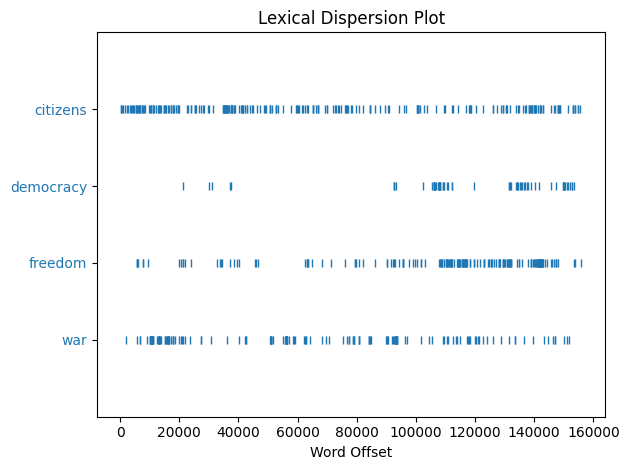

In [3]:
import matplotlib.pyplot as plt

text4.dispersion_plot(['citizens', 'democracy', 'freedom', 'war'])
plt.tight_layout()
plt.show()

**Observations:**

| Word | Trend |
|------|-------|
| **citizens** | Appears consistently throughout history; a foundational term from the founding era onward. |
| **democracy** | Rare in early addresses (Founders preferred *republic*); becomes much more frequent in the 20th century, especially post-WWII. |
| **freedom** | Spikes sharply during the Civil War era and again after WWII — periods where the concept was most contested. |
| **war** | Clusters around major conflicts (War of 1812, Civil War, WWI, WWII, Cold War); notably absent in peacetime periods. |

**Key insight:** Dispersion plots reveal how *political vocabulary shifts over time* in response to historical events.  
This is a form of **diachronic corpus analysis** — studying language change across time.

> Note: The x-axis represents word *position* in the concatenated corpus, not calendar year, so each "band" corresponds roughly to one presidential address.

---
## Exercise 1.3

**Task:** Find all words in `text1` (Moby Dick) longer than 15 characters that appear more than once.

In [4]:
from nltk import FreqDist

fdist1 = FreqDist(text1)

long_repeated = sorted(
    [word for word in fdist1
     if len(word) > 15 and fdist1[word] > 1],
    key=lambda w: (-fdist1[w], w)   # sort by frequency desc, then alphabetically
)

print(f'Words in Moby Dick longer than 15 characters appearing more than once: {len(long_repeated)}')
print(f'{"Word":<30} {"Length":>6} {"Count":>6}')
print('-' * 44)
for word in long_repeated:
    print(f'{word:<30} {len(word):>6} {fdist1[word]:>6}')

Words in Moby Dick longer than 15 characters appearing more than once: 8
Word                           Length  Count
--------------------------------------------
apprehensiveness                   16      4
comprehensiveness                  17      3
indiscriminately                   16      3
circumnavigating                   16      2
circumnavigation                   16      2
physiognomically                   16      2
simultaneousness                   16      2
superstitiousness                  17      2


**What to notice:**

- Most are compound or hyphenated technical/nautical terms (e.g. *`half-comprehending`*, *`unconditionally`*).
- Some are punctuation-adjacent tokens (Melville's 19th-century typesetting) — a reminder that real corpora contain **noise**.
- The list is small: very long words that recur are rare in any natural-language text. This illustrates **Zipf's Law** — word frequency decreases sharply with rank.

**Alternative one-liner using a set comprehension:**
```python
long_words = {w for w in set(text1) if len(w) > 15 and text1.count(w) > 1}
```
The `FreqDist` approach is preferred because `text1.count()` scans the entire list each call — O(n) per word — whereas `FreqDist` pre-computes all counts in a single O(n) pass.

---
## Exercise 1.4

**Task:** Build a frequency distribution for `text6` (Monty Python). What are the most common content words (non-stopwords)?

In [5]:
from nltk import FreqDist
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

stop_words = set(stopwords.words('english'))

# Keep only alphabetic, lowercase, non-stopword tokens
content_tokens = [
    w.lower() for w in text6
    if w.isalpha() and w.lower() not in stop_words
]

fdist6 = FreqDist(content_tokens)

print(f'Total tokens in text6:          {len(text6):,}')
print(f'After stopword removal:          {len(content_tokens):,}')
print(f'Unique content word types:       {len(fdist6):,}')
print()
print('Top 20 content words in Monty Python:')
print(f'{"Word":<20} {"Count":>6}')
print('-' * 28)
for word, count in fdist6.most_common(20):
    print(f'{word:<20} {count:>6}')

Total tokens in text6:          16,967
After stopword removal:          6,692
Unique content word types:       1,667

Top 20 content words in Monty Python:
Word                  Count
----------------------------
arthur                  261
oh                      112
launcelot               101
knight                   84
galahad                  80
father                   75
sir                      72
ni                       69
bedevere                 67
knights                  65
well                     62
head                     59
ha                       59
robin                    58
right                    55
guard                    55
yes                      53
villager                 47
boom                     45
come                     44


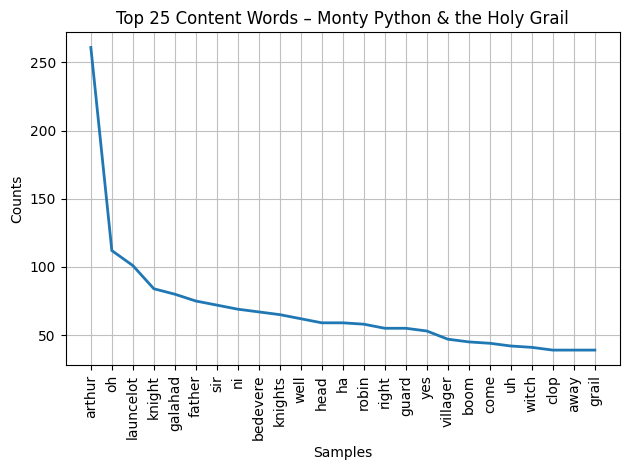

In [6]:
fdist6.plot(25, title='Top 25 Content Words – Monty Python & the Holy Grail')
plt.tight_layout()
plt.show()

**Observations:**

- Words like *`sir`*, *`knight`*, *`king`*, *`arthur`* dominate — consistent with the medieval setting of the film.
- *`ni`* ("We are the Knights who say NI!") and *`swallow`* (the airspeed velocity debate) rank highly — hallmarks of the script's famous scenes.
- Removing stopwords cuts the token count significantly but makes the *meaningful* vocabulary much clearer.
- This technique — building a **content-word frequency distribution** — is a core method in **corpus linguistics** and forms the basis of more advanced techniques like TF-IDF (covered in Week 3).

**Extension:** Try repeating this for `text1` (Moby Dick) and compare — what does the top vocabulary tell you about each text's subject matter?

---
## Summary of Key Concepts

| Exercise | Concept Practiced |
|----------|------------------|
| 1.1 | Type-token ratio; vocabulary richness; effect of text length |
| 1.2 | Diachronic corpus analysis; dispersion plots; historical language change |
| 1.3 | FreqDist; filtering by length and frequency; Zipf's Law |
| 1.4 | Stopword removal; content-word frequency; corpus linguistics foundations |

---
*NLP Course 2027 — Week 01*